In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

sys.path.insert(0, '..')

FEDAVG_RESULTS  = '../02_FedAvg/results'
FEDGEN_RESULTS  = '../03_FedGen/results'
ALPHA_SWEEP     = [0.5, 1.0, 5.0]
SEEDS           = [42, 123, 7]
CENTRALIZED_AUC = 0.658

# ── Color palette ─────────────────────────────────────────────────────────────
# Four fully distinct colors — two per method family, distinguishable both
# by color and by line style. Tested for colorblind accessibility.
#
#   FedAvg  family → blue  tones  (dark=full, light=partial)
#   FedGen  family → warm  tones  (red=full, orange=partial)
#
# Using solid lines for full-sharing and dashed for partial-sharing.
# Markers every N rounds prevent line-style confusion at small sizes.

VARIANTS = {
    'fedavg_full':    {'label': 'FedAvg (full)',    'color': '#1f77b4', 'ls': '-',  'marker': 'o'},
    'fedavg_partial': {'label': 'FedAvg (partial)', 'color': '#7fbfdf', 'ls': '--', 'marker': 's'},
    'fedgen_full':    {'label': 'FedGen (full)',     'color': '#d62728', 'ls': '-',  'marker': 'o'},
    'fedgen_partial': {'label': 'FedGen (partial)',  'color': '#ff7f0e', 'ls': '--', 'marker': 's'},
}

plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
    'axes.prop_cycle':   plt.cycler(color=[v['color'] for v in VARIANTS.values()]),
})

os.makedirs('figures', exist_ok=True)


def load_results(alpha_sweep, seeds, variants):
    data = {}
    for alpha in alpha_sweep:
        data[alpha] = {}
        for variant in variants:
            results_dir = FEDGEN_RESULTS if variant.startswith('fedgen') else FEDAVG_RESULTS
            aucs, per_client, histories, mbs = [], [], [], []
            for seed in seeds:
                p = os.path.join(results_dir, f'alpha_{alpha}',
                                 f'seed_{seed}', f'{variant}.json')
                if os.path.exists(p):
                    r = json.load(open(p))
                    aucs.append(r['test_auc'])
                    per_client.append(r['per_client'])
                    histories.append(r['history'])
                    mbs.append(r['cumul_mb'])
                else:
                    print(f'Warning: Missing {p}')
            data[alpha][variant] = {
                'test_aucs':  aucs,
                'per_client': per_client,
                'histories':  histories,
                'cumul_mbs':  mbs,
            }
    return data


results = load_results(ALPHA_SWEEP, SEEDS, VARIANTS)
print('Results loaded.')

Results loaded.


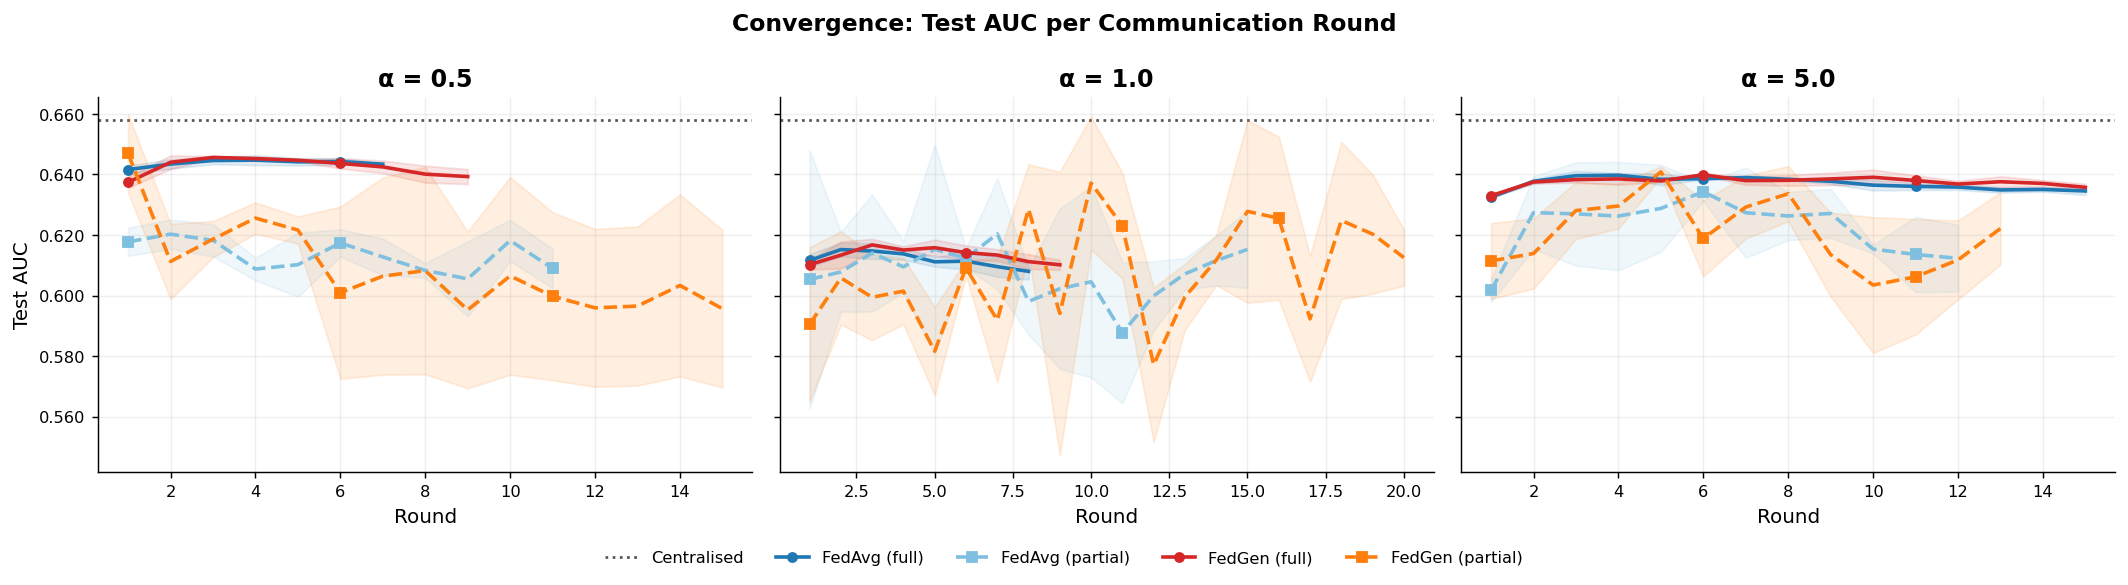

In [2]:
# Figure 1: Test AUC vs Communication Rounds
# One column per alpha. Markers every 5 rounds prevent confusion between
# solid and dashed lines when printed in grayscale.

MARKER_EVERY = 5

fig, axes = plt.subplots(1, len(ALPHA_SWEEP),
                         figsize=(5.5 * len(ALPHA_SWEEP), 4.2),
                         sharey=True)
fig.suptitle('Convergence: Test AUC per Communication Round',
             fontweight='bold', fontsize=13)

for ax, alpha in zip(axes, ALPHA_SWEEP):
    ax.axhline(CENTRALIZED_AUC, color='#555555', linestyle=':',
               linewidth=1.5, label='Centralised', zorder=1)

    for vname, vinfo in VARIANTS.items():
        d = results[alpha][vname]
        if not d['histories']:
            continue
        max_len = max(len(h) for h in d['histories'])
        padded  = [h + [h[-1]] * (max_len - len(h)) for h in d['histories']]
        vals    = np.array([[step['test'] for step in h] for h in padded])
        mean, std = vals.mean(0), vals.std(0)
        rounds = np.arange(1, max_len + 1)

        # Shaded std band drawn first (behind the line)
        ax.fill_between(rounds, mean - std, mean + std,
                        color=vinfo['color'], alpha=0.12, zorder=2)
        # Main line with periodic markers
        ax.plot(rounds, mean,
                color=vinfo['color'], ls=vinfo['ls'], linewidth=2,
                marker=vinfo['marker'], markevery=MARKER_EVERY,
                markersize=5, label=vinfo['label'], zorder=3)

    ax.set_title(f'α = {alpha}', fontweight='bold')
    ax.set_xlabel('Round')
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

axes[0].set_ylabel('Test AUC')

# Single shared legend below all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(VARIANTS) + 1,
           fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('figures/fig1_convergence_rounds.png',
            dpi=150, bbox_inches='tight')
plt.show()

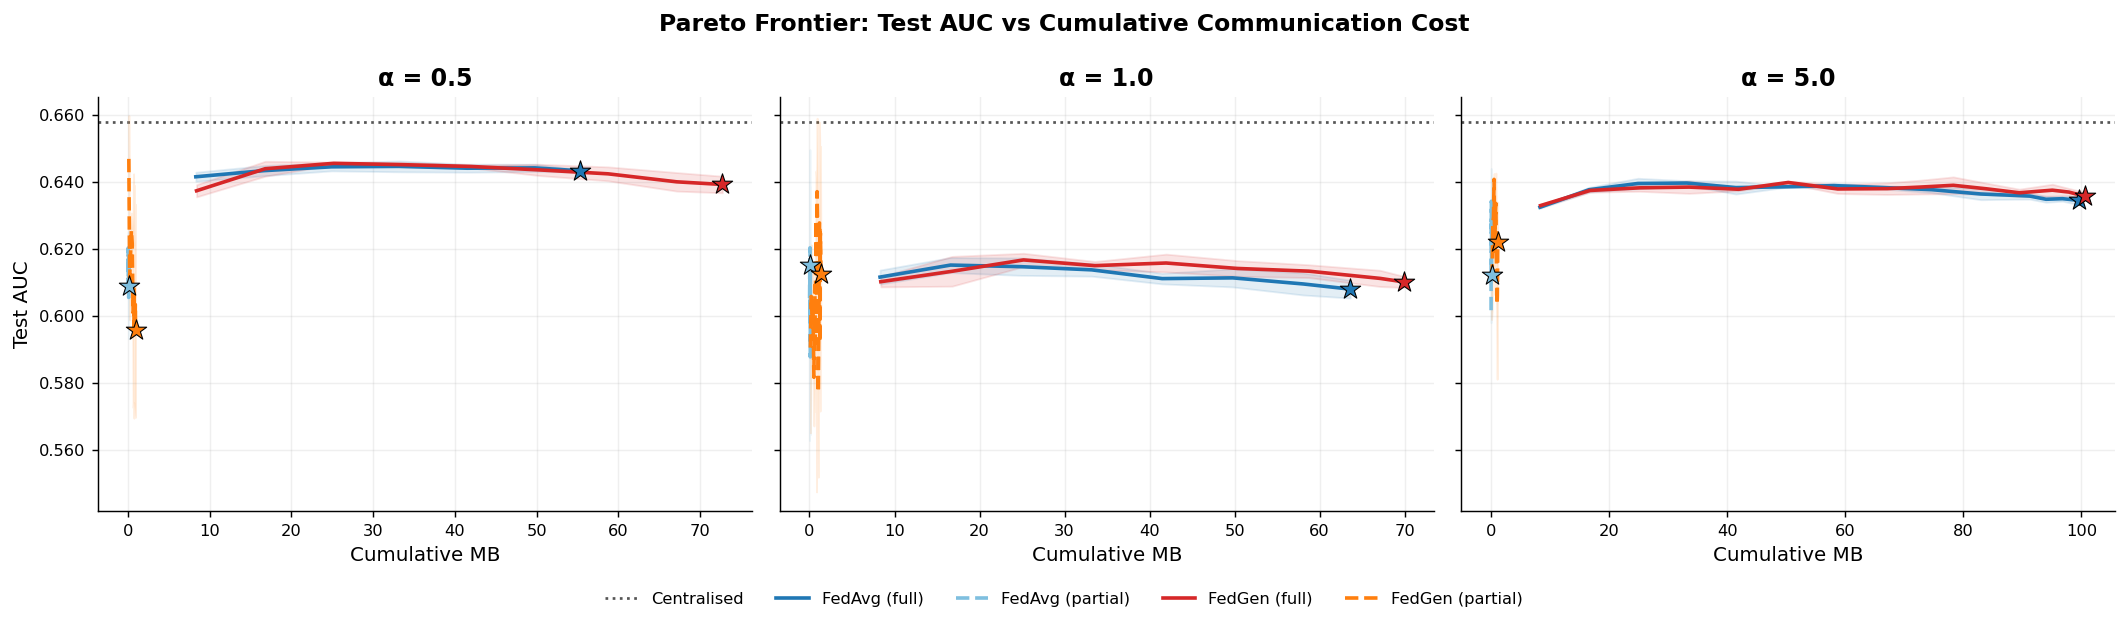

In [3]:
# Figure 2: Pareto Frontier — Test AUC vs Cumulative Communication Cost (MB)
# Each curve is a trajectory from round 1 to the final round.
# Endpoint star markers show the best-round operating point.
# This is the central thesis figure: FedGen partial achieves similar AUC
# to FedAvg full at a fraction of the communication cost.

fig, axes = plt.subplots(1, len(ALPHA_SWEEP),
                         figsize=(5.5 * len(ALPHA_SWEEP), 4.5),
                         sharey=True)
fig.suptitle('Pareto Frontier: Test AUC vs Cumulative Communication Cost',
             fontweight='bold', fontsize=13)

for ax, alpha in zip(axes, ALPHA_SWEEP):
    ax.axhline(CENTRALIZED_AUC, color='#555555', linestyle=':',
               linewidth=1.5, label='Centralised', zorder=1)

    for vname, vinfo in VARIANTS.items():
        d = results[alpha][vname]
        if not d['histories']:
            continue
        max_len   = max(len(h)  for h in d['histories'])
        max_len_m = max(len(m)  for m in d['cumul_mbs'])
        common    = min(max_len, max_len_m)

        padded_h  = [h + [h[-1]]  * (common - len(h))  for h in d['histories']]
        padded_mb = [m + [m[-1]]  * (common - len(m))  for m in d['cumul_mbs']]

        vals = np.array([[step['test'] for step in h[:common]] for h in padded_h])
        mbs  = np.array([m[:common] for m in padded_mb])

        mean_v  = vals.mean(0)
        std_v   = vals.std(0)
        mean_mb = mbs.mean(0)

        ax.fill_between(mean_mb, mean_v - std_v, mean_v + std_v,
                        color=vinfo['color'], alpha=0.12, zorder=2)
        ax.plot(mean_mb, mean_v,
                color=vinfo['color'], ls=vinfo['ls'], linewidth=2,
                label=vinfo['label'], zorder=3)

        # Endpoint star — shows final operating point clearly
        ax.scatter(mean_mb[-1], mean_v[-1],
                   color=vinfo['color'], marker='*', s=140,
                   edgecolors='black', linewidth=0.6, zorder=5)

    ax.set_title(f'α = {alpha}', fontweight='bold')
    ax.set_xlabel('Cumulative MB')
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

axes[0].set_ylabel('Test AUC')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(VARIANTS) + 1,
           fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('figures/fig2_pareto_frontier.png',
            dpi=150, bbox_inches='tight')
plt.show()

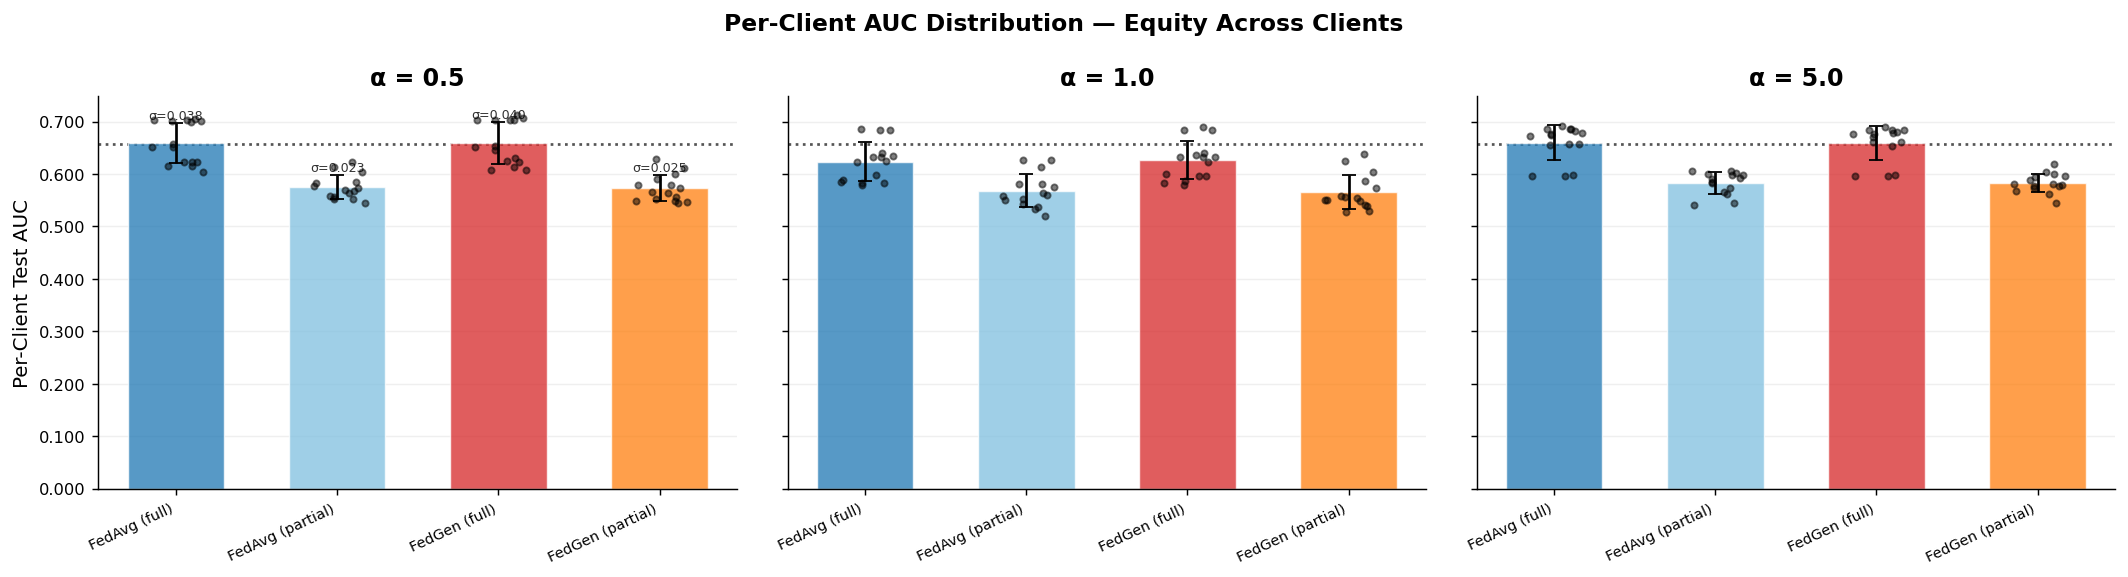

In [4]:
# Figure 3: Per-Client AUC — Equity Dimension
# Grouped bar chart (mean ± std across seeds) with individual client-seed
# points overlaid as dots. 15 points per variant (5 clients × 3 seeds).
# The centralized line is the equity ceiling: a perfect FL system would
# have all clients at this level with zero variance.

fig, axes = plt.subplots(1, len(ALPHA_SWEEP),
                         figsize=(5.5 * len(ALPHA_SWEEP), 4.5),
                         sharey=True)
fig.suptitle('Per-Client AUC Distribution — Equity Across Clients',
             fontweight='bold', fontsize=13)

x_positions = np.arange(len(VARIANTS))
bar_width   = 0.6

for ax, alpha in zip(axes, ALPHA_SWEEP):
    for j, (vname, vinfo) in enumerate(VARIANTS.items()):
        d = results[alpha][vname]
        all_aucs = []
        for pc in d['per_client']:
            all_aucs.extend(list(pc.values()))
        if not all_aucs:
            continue

        mean_auc = np.mean(all_aucs)
        std_auc  = np.std(all_aucs)

        ax.bar(x_positions[j], mean_auc, bar_width,
               color=vinfo['color'], alpha=0.75,
               edgecolor='white', linewidth=0.8, zorder=2)
        ax.errorbar(x_positions[j], mean_auc, yerr=std_auc,
                    fmt='none', color='black', capsize=4,
                    linewidth=1.5, zorder=3)

        # Individual points — jittered so they don't overlap
        rng    = np.random.default_rng(42)
        jitter = rng.uniform(-0.18, 0.18, len(all_aucs))
        ax.scatter(x_positions[j] + jitter, all_aucs,
                   color='black', s=12, alpha=0.5, zorder=4)

    ax.axhline(CENTRALIZED_AUC, color='#555555', linestyle=':',
               linewidth=1.5, label='Centralised', zorder=1)

    ax.set_title(f'α = {alpha}', fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels([v['label'] for v in VARIANTS.values()],
                       rotation=25, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, axis='y', zorder=0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

axes[0].set_ylabel('Per-Client Test AUC')

# Variance annotation: add std value above each bar for the first alpha
for j, (vname, vinfo) in enumerate(VARIANTS.items()):
    d = results[ALPHA_SWEEP[0]][vname]
    all_aucs = []
    for pc in d['per_client']:
        all_aucs.extend(list(pc.values()))
    if all_aucs:
        axes[0].text(x_positions[j], np.mean(all_aucs) + np.std(all_aucs) + 0.002,
                     f'σ={np.std(all_aucs):.3f}',
                     ha='center', va='bottom', fontsize=7, color='#333333')

plt.tight_layout()
plt.savefig('figures/fig3_equity_per_client.png',
            dpi=150, bbox_inches='tight')
plt.show()

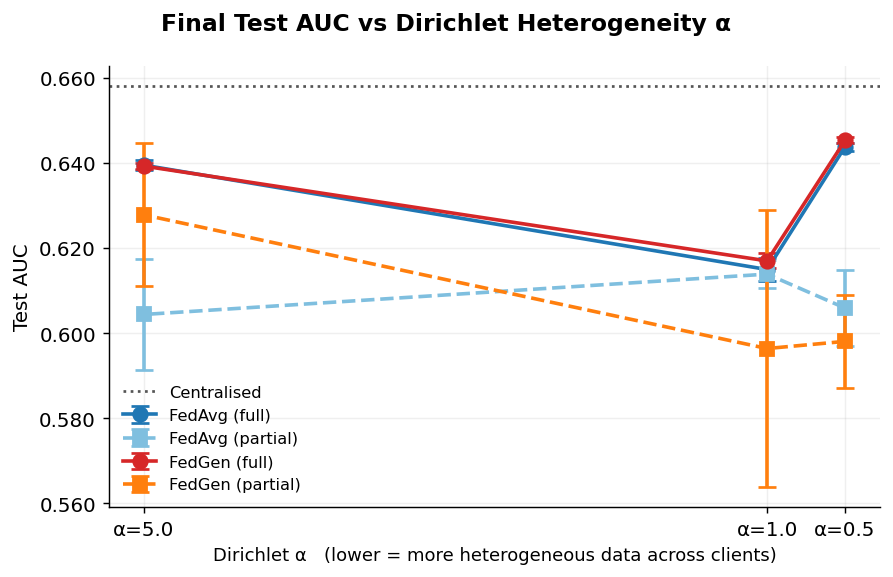

In [5]:
# Figure 4: Final Test AUC vs Heterogeneity Level (α)
# Follows Zhu et al. Figure 5 style: x-axis = alpha, left = more heterogeneous.
# Error bars = std across seeds. Markers distinguish variants.

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.suptitle('Final Test AUC vs Dirichlet Heterogeneity α',
             fontweight='bold', fontsize=13)

ax.axhline(CENTRALIZED_AUC, color='#555555', linestyle=':',
           linewidth=1.5, label='Centralised', zorder=1)

for vname, vinfo in VARIANTS.items():
    means, stds = [], []
    for alpha in ALPHA_SWEEP:
        aucs = results[alpha][vname]['test_aucs']
        means.append(np.mean(aucs) if aucs else np.nan)
        stds.append(np.std(aucs)   if aucs else 0.0)

    ax.errorbar(ALPHA_SWEEP, means, yerr=stds,
                color=vinfo['color'], ls=vinfo['ls'],
                linewidth=2, marker=vinfo['marker'], markersize=8,
                capsize=5, capthick=1.5,
                label=vinfo['label'], zorder=3)

ax.set_xlabel('Dirichlet α   (lower = more heterogeneous data across clients)',
              fontsize=10)
ax.set_ylabel('Test AUC')
ax.set_xticks(ALPHA_SWEEP)
ax.set_xticklabels([f'α={a}' for a in ALPHA_SWEEP])
ax.invert_xaxis()   # most heterogeneous on the left, matching Zhu Fig 5
ax.legend(fontsize=9, frameon=False)
ax.grid(alpha=0.2, zorder=0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig('figures/fig4_auc_vs_alpha.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
import pandas as pd

rows = []
for alpha in ALPHA_SWEEP:
    for vname, vinfo in VARIANTS.items():
        d    = results[alpha][vname]
        aucs = d['test_aucs']
        if not aucs:
            continue

        # Per-client AUC variance across all seeds
        all_pc_aucs = []
        for pc in d['per_client']:
            all_pc_aucs.extend(list(pc.values()))

        rows.append({
            'α':            alpha,
            'Variant':      vinfo['label'],
            'Mean AUC':     round(np.mean(aucs),        4),
            'Std AUC':      round(np.std(aucs),         4),
            'Client σ':     round(np.std(all_pc_aucs),  4),  # equity metric
            'Rounds':       round(np.mean([len(h) for h in d['histories']]), 1),
            'Final MB':     round(np.mean([m[-1] for m in d['cumul_mbs']]), 2),
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

  α          Variant  Mean AUC  Std AUC  Client σ  Rounds  Final MB
0.5    FedAvg (full)    0.6438   0.0010    0.0382     6.7     55.31
0.5 FedAvg (partial)    0.6059   0.0089    0.0226     9.3      0.09
0.5    FedGen (full)    0.6453   0.0007    0.0398     8.7     72.71
0.5 FedGen (partial)    0.5981   0.0109    0.0250     9.0      0.93
1.0    FedAvg (full)    0.6150   0.0027    0.0369     7.7     63.60
1.0 FedAvg (partial)    0.6139   0.0034    0.0317    11.0      0.11
1.0    FedGen (full)    0.6170   0.0018    0.0358     8.3     69.91
1.0 FedGen (partial)    0.5964   0.0326    0.0327    13.0      1.34
5.0    FedAvg (full)    0.6395   0.0011    0.0332    12.0     99.55
5.0 FedAvg (partial)    0.6044   0.0131    0.0204    10.7      0.10
5.0    FedGen (full)    0.6393   0.0008    0.0326    12.0    100.67
5.0 FedGen (partial)    0.6278   0.0168    0.0176    11.0      1.14
